In [133]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.optimize import root_scalar
R = 8.314462618     
P0 = 1.0  
T_ref = 298.15          


In [134]:
def adom(x,y,m,n):
    A=np.array([x,y,m,n])
    return A

def element_balance(n,A,b):
    return A @ n - b

def gibbs_total(n, T, P, g0):
    n = np.asarray(n, dtype=float)
    g0 = np.asarray(g0, dtype=float)

    if np.any(n < 0):
        return np.inf

    n_total = np.sum(n)

    if n_total <= 0:
        return np.inf
    
    y = n / n_total

    mask = n > 0

    chemical_potential = (
        g0[mask]
        + R * T * np.log(y[mask] * P / P0)
    )

    G = np.sum(n[mask] * chemical_potential)

    return G

#热容系数是常数的时候的HSG的计算方程：
def g_standard(T, Hf298, S298, Cp):
    H = Hf298 + Cp * (T - T_ref)
    S = S298 + Cp * np.log(T / T_ref)

    G = H - T * S

    return G

def composition_from_x(x):
    n = np.array([
        x,                  # CH3NO2
        1 - x,              # CO2
        0.0,                # H2O
        (1 - x) / 2,        # N2
        3 * (1 - x) / 2     # H2
    ], dtype=float)
    
    return n

def G_of_x(x,T,P,g0):
    n = composition_from_x(x)
    G = gibbs_total(n, T, P, g0)
    return float(G)

def h_standard(T, Hf298, Cp):
    H = Hf298 + Cp * (T - T_ref)
    return H

def equilibrium_at_T(T, P):

    # 这个温度下重新计算标准 Gibbs 能
    g0 = g_standard(
        T,
        Hf298,
        S298,
        Cp
    )

    # 定义这个温度下的 G(x)
    def objective(x):
        n = composition_from_x(x)
        return gibbs_total(n, T, P, g0)

    # Gibbs 最小化
    result = minimize_scalar(
        objective,
        bounds=(0.0, 1.0),
        method="bounded"
    )

    n_eq = composition_from_x(result.x)

    return n_eq


def total_enthalpy(n, T):

    h = h_standard(
        T,
        Hf298,
        Cp
    )

    H_total = np.dot(n, h)

    return H_total

def enthalpy_residual(T):

    # 这个温度下先重新求化学平衡
    n_eq = equilibrium_at_T(
        T,
        P
    )

    # 再计算这个平衡状态的总焓
    H_final = total_enthalpy(
        n_eq,
        T
    )

    # 希望这个值最后等于 0
    residual = H_final - H_initial

    return residual


In [135]:
#CH3NO2的元素守恒的检验
species = {
    "CH3NO2": [1, 3, 1, 2],
    "CO2":    [1, 0, 0, 2],
    "H2O":    [0, 2, 0, 1],
    "N2":     [0, 0, 2, 0],
    "H2":     [0, 2, 0, 0]
}

A = np.array(list(species.values()), dtype=float).T

b = np.array([1, 3, 1, 2], dtype=float)

n0 = np.array([1, 0, 0, 0, 0], dtype=float)


print("A =")
print(A)

print("元素守恒残差 =", element_balance(n0,A,b))



A =
[[1. 1. 0. 0. 0.]
 [3. 0. 2. 0. 2.]
 [1. 0. 0. 2. 0.]
 [2. 2. 1. 0. 0.]]
元素守恒残差 = [0. 0. 0. 0.]


In [136]:
#计算的数据的导入的内容：
Hf298 = np.array([
    -40000 ,   # CH3NO2
    -120000 ,   # CO2
    -90000,   # H2O
    0 ,   # N2
    0     # H2
], dtype=float)

S298 = np.array([
    220,
    180,
    170,
    160,
    130
], dtype=float)

Cp = np.array([
    55,
    35,
    32,
    29,
    28
], dtype=float)
T = 400.0
P = 1.0

g0 = g_standard(T, Hf298, S298, Cp)

print(g0)

T_initial = 298.15
P = 1.0

n_initial = np.array([
    1.0,    # CH3NO2
    0.0,    # CO2
    0.0,    # H2O
    0.0,    # N2
    0.0     # H2
])

H_initial = total_enthalpy(
    n_initial,
    T_initial
)

print("初始总焓 =", H_initial, "J")

[-128863.34229386 -192549.39964154 -158502.3082437   -64455.21684585
  -52439.51971324]
初始总焓 = -40000.0 J


In [137]:
#text的数据以及数据优化：
n_test = composition_from_x(0.5)
print(n_test)
print("元素守恒残差：", A @ n_test - b)

print(G_of_x(0.0,T,P,g0))
print(G_of_x(0.5,T,P,g0))
print(G_of_x(1.0,T,P,g0))


[0.5  0.5  0.   0.25 0.75]
元素守恒残差： [0. 0. 0. 0.]
-313527.42717503663
-224935.7963654224
-128863.34229385508


In [138]:
result = minimize_scalar(
    G_of_x,
    bounds=(0.0, 1.0),
    method="bounded",
    args=(T, P, g0)
)
print("优化成功：", result.success)
print("最低点 x =", result.x)
print("G_min =", result.fun)

n_eq = composition_from_x(result.x)

print("对应组成 =", n_eq)
print("守恒残差 =", A @ n_eq - b)

优化成功： True
最低点 x = 5.9608609865491405e-06
G_min = -313526.6065171321
对应组成 = [5.96086099e-06 9.99994039e-01 0.00000000e+00 4.99997020e-01
 1.49999106e+00]
守恒残差 = [0. 0. 0. 0.]


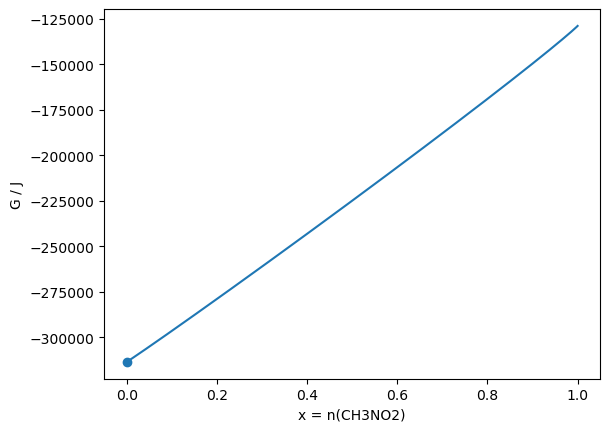

In [139]:
x_values = np.linspace(1e-6, 1.0, 500)

G_values = np.array([
    G_of_x(x, T, P, g0)
    for x in x_values
])

plt.plot(x_values, G_values)

plt.scatter(
    result.x,
    result.fun
)

plt.xlabel("x = n(CH3NO2)")
plt.ylabel("G / J")
plt.show()

In [140]:
print(equilibrium_at_T(400.0, 1.0))
T_result = root_scalar(
    enthalpy_residual,
    bracket=(1000.0, 1200.0),
    method="brentq"
)

T_eq = T_result.root

print("求解成功：", T_result.converged)
print("最终温度 =", T_eq, "K")
n_eq = equilibrium_at_T(
    T_eq,
    P
)

print("最终温度 =", T_eq, "K")
print("最终平衡组成 =", n_eq)

print(
    "元素守恒残差 =",
    A @ n_eq - b
)

print(
    "焓守恒残差 =",
    enthalpy_residual(T_eq),
    "J"
)

[5.96086099e-06 9.99994039e-01 0.00000000e+00 4.99997020e-01
 1.49999106e+00]
求解成功： True
最终温度 = 1172.4638071783922 K
最终温度 = 1172.4638071783922 K
最终平衡组成 = [5.96086099e-06 9.99994039e-01 0.00000000e+00 4.99997020e-01
 1.49999106e+00]
元素守恒残差 = [0. 0. 0. 0.]
焓守恒残差 = 7.275957614183426e-12 J
